Cell 1 — Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from pathlib import Path

sys.path.append(str(Path("../src/models").resolve()))
sys.path.append(str(Path("../src/physics").resolve()))
sys.path.append(str(Path("../src/data").resolve()))
sys.path.append(str(Path("../src/evaluation").resolve()))

from cnn import HeatSurrogateCNN
from heat_solver import make_grid, run_simulation, compute_stable_dt
from boundary_conditions import apply_dirichlet_zero
from metrics import mse, relative_l2, max_absolute_error

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("../results/best_model.pt", map_location=device)
model      = HeatSurrogateCNN(n_filters=32).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Model loaded — epoch {checkpoint['epoch']}, "
      f"val loss {checkpoint['val_loss']:.2e}")
print(f"Device: {device}")

Model loaded — epoch 19, val loss 7.28e-06
Device: cpu


Cell 2 — Rollout utility functions

In [2]:
def solver_rollout(T0, alpha, dx, n_steps, stride):
    """
    Run the solver for n_steps * stride total steps.
    Return snapshots at every stride-th step.

    This gives the ground truth trajectory that the CNN
    rollout will be compared against.

    Parameters
    ----------
    T0     : np.ndarray (N, N)  Initial condition.
    alpha  : float              Thermal diffusivity.
    dx     : float              Grid spacing.
    n_steps: int                Number of CNN steps to simulate.
    stride : int                Solver steps per CNN step.

    Returns
    -------
    snapshots : np.ndarray (n_steps+1, N, N)
                T at rollout steps 0, 1, 2, ..., n_steps
    """
    total_steps = n_steps * stride
    snaps, _, _, _ = run_simulation(
        T0, alpha, dx,
        n_steps    = total_steps,
        save_every = stride,
    )
    return snaps   # shape (n_steps+1, N, N)


@torch.no_grad()
def cnn_rollout(model, T0, n_steps, device):
    """
    Run autoregressive CNN rollout for n_steps steps.

    At each step, feed the previous CNN prediction back
    as input. This is the core autoregressive loop.

    Parameters
    ----------
    model  : HeatSurrogateCNN
    T0     : np.ndarray (N, N)  Initial condition.
    n_steps: int                Number of rollout steps.
    device : torch.device

    Returns
    -------
    snapshots : np.ndarray (n_steps+1, N, N)
                T̂ at rollout steps 0, 1, 2, ..., n_steps
    """
    N         = T0.shape[0]
    snapshots = np.zeros((n_steps + 1, N, N), dtype=np.float32)
    snapshots[0] = T0

    # convert initial condition to tensor
    T_current = torch.from_numpy(T0).float().unsqueeze(0).unsqueeze(0).to(device)
    # shape: (1, 1, N, N)

    for step in range(1, n_steps + 1):
        T_next    = model(T_current)          # (1, 1, N, N)
        T_current = T_next                    # feed prediction back as input
        snapshots[step] = T_next.squeeze().cpu().numpy()

    return snapshots

Cell 3 — Single rollout: visual comparison

In [3]:
# parameters matching your dataset generation
N      = 64
L      = 1.0
alpha  = 0.01
stride = 10       # must match dataset generation stride

x, y, dx = make_grid(N, L)
dt, r    = compute_stable_dt(dx, alpha)

# fixed initial condition: single centered blob
rng  = np.random.default_rng(123)
cx   = rng.uniform(0.25, 0.75)
cy   = rng.uniform(0.25, 0.75)
sig  = 0.08
X, Y = np.meshgrid(x, y)
T0   = np.exp(-((X-cx)**2 + (Y-cy)**2) / (2*sig**2)).astype(np.float32)
T0   = apply_dirichlet_zero(T0)

# how many CNN steps to roll out
n_rollout = 20   # 20 CNN steps = 200 solver steps of physical time

print(f"Running solver rollout   ({n_rollout} CNN steps = "
      f"{n_rollout*stride} solver steps)...")
true_snaps = solver_rollout(T0, alpha, dx, n_rollout, stride)

print(f"Running CNN rollout      ({n_rollout} steps)...")
cnn_snaps  = cnn_rollout(model, T0, n_rollout, device)

print(f"Solver snapshots shape : {true_snaps.shape}")
print(f"CNN snapshots shape    : {cnn_snaps.shape}")

Running solver rollout   (20 CNN steps = 200 solver steps)...
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 1.1338
Running CNN rollout      (20 steps)...
Solver snapshots shape : (21, 64, 64)
CNN snapshots shape    : (21, 64, 64)


Cell 4 — Visualize rollout side by side

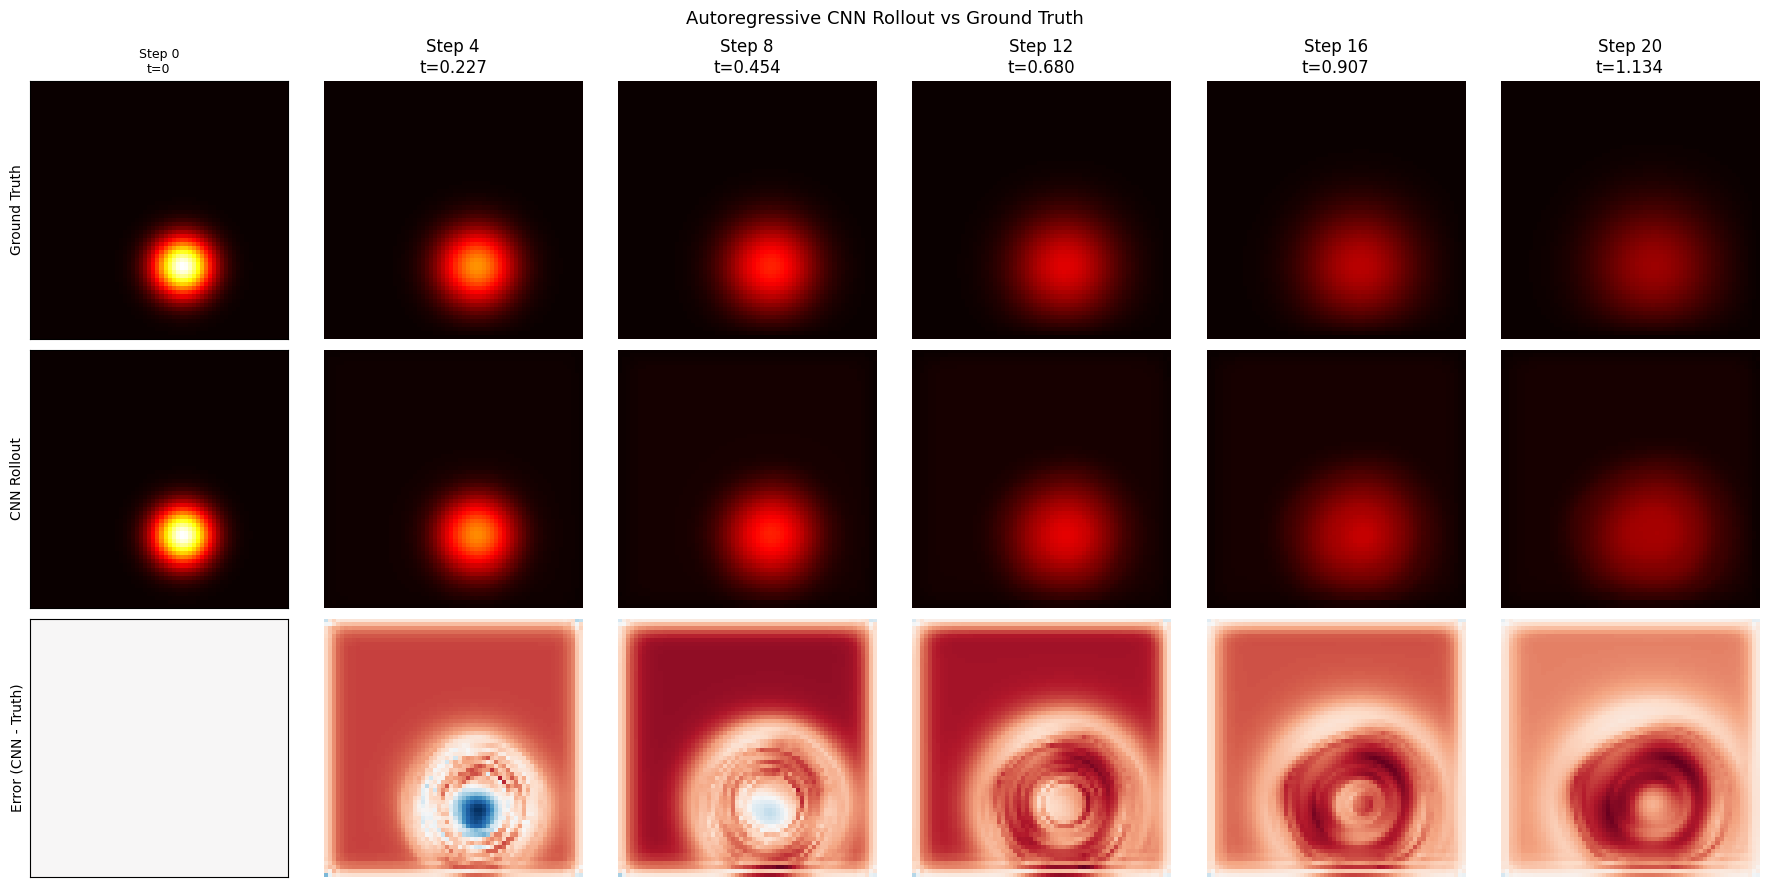

In [4]:
# show every 4th rollout step: steps 0, 4, 8, 12, 16, 20
display_steps = [0, 4, 8, 12, 16, 20]
n_display     = len(display_steps)

fig, axes = plt.subplots(3, n_display, figsize=(18, 9))

vmin = 0.0
vmax = T0.max()

for col, step in enumerate(display_steps):
    true = true_snaps[step]
    cnn  = cnn_snaps[step]
    err  = cnn - true

    axes[0, col].imshow(true, origin="lower", cmap="hot",
                        vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f"Step {step}\nt={step*stride*dt:.3f}")
    axes[0, col].axis("off")

    axes[1, col].imshow(cnn, origin="lower", cmap="hot",
                        vmin=vmin, vmax=vmax)
    axes[1, col].axis("off")

    err_scale = max(np.abs(err).max(), 1e-6)
    im = axes[2, col].imshow(err, origin="lower", cmap="RdBu_r",
                              vmin=-err_scale, vmax=err_scale)
    axes[2, col].axis("off")

axes[0, 0].set_title(f"Step 0\nt=0", fontsize=9)
for row, label in enumerate(["Ground Truth", "CNN Rollout", "Error (CNN - Truth)"]):
    axes[row, 0].set_ylabel(label, fontsize=10)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

plt.suptitle("Autoregressive CNN Rollout vs Ground Truth", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone8_rollout_visual.png", dpi=150)
plt.show()

Cell 5 — Error accumulation curves (the key experiment)

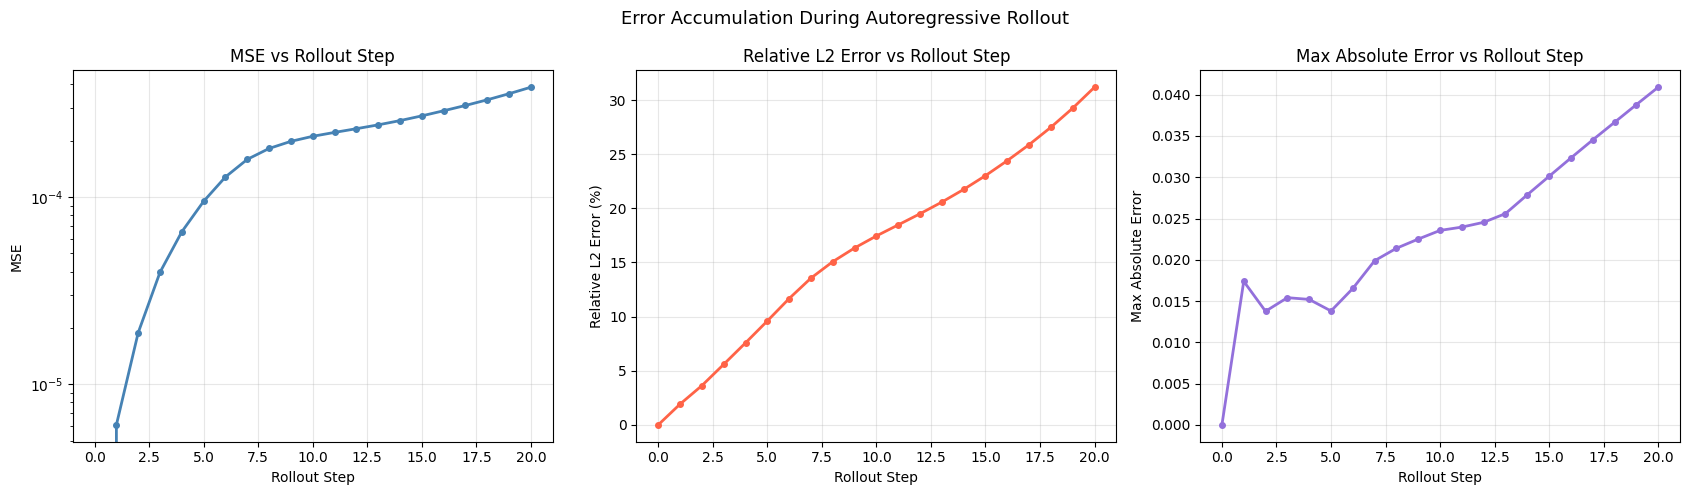


Error accumulation summary:
  Step  0 : MSE=0.00e+00  RelL2=0.000%
  Step  5 : MSE=9.49e-05  RelL2=9.595%
  Step 10 : MSE=2.11e-04  RelL2=17.447%
  Step 20 : MSE=3.86e-04  RelL2=31.187%

  Error growth factor (step 20 / step 1): 16.28x


In [5]:
# compute error metrics at every rollout step
mse_curve     = np.zeros(n_rollout + 1)
rel_l2_curve  = np.zeros(n_rollout + 1)
max_ae_curve  = np.zeros(n_rollout + 1)

for step in range(n_rollout + 1):
    true = true_snaps[step]
    cnn  = cnn_snaps[step]

    mse_curve[step]    = mse(cnn, true)
    rel_l2_curve[step] = relative_l2(cnn, true)
    max_ae_curve[step] = max_absolute_error(cnn, true)

steps      = np.arange(n_rollout + 1)
phys_times = steps * stride * dt

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(steps, mse_curve, color="steelblue", linewidth=2, marker="o",
             markersize=4)
axes[0].set_xlabel("Rollout Step")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE vs Rollout Step")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")

axes[1].plot(steps, rel_l2_curve * 100, color="tomato", linewidth=2,
             marker="o", markersize=4)
axes[1].set_xlabel("Rollout Step")
axes[1].set_ylabel("Relative L2 Error (%)")
axes[1].set_title("Relative L2 Error vs Rollout Step")
axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, max_ae_curve, color="mediumpurple", linewidth=2,
             marker="o", markersize=4)
axes[2].set_xlabel("Rollout Step")
axes[2].set_ylabel("Max Absolute Error")
axes[2].set_title("Max Absolute Error vs Rollout Step")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Error Accumulation During Autoregressive Rollout", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone8_error_accumulation.png", dpi=150)
plt.show()

print(f"\nError accumulation summary:")
print(f"  Step  0 : MSE={mse_curve[0]:.2e}  RelL2={rel_l2_curve[0]*100:.3f}%")
print(f"  Step  5 : MSE={mse_curve[5]:.2e}  RelL2={rel_l2_curve[5]*100:.3f}%")
print(f"  Step 10 : MSE={mse_curve[10]:.2e}  RelL2={rel_l2_curve[10]*100:.3f}%")
print(f"  Step 20 : MSE={mse_curve[20]:.2e}  RelL2={rel_l2_curve[20]*100:.3f}%")
print(f"\n  Error growth factor (step 20 / step 1): "
      f"{rel_l2_curve[20]/max(rel_l2_curve[1], 1e-10):.2f}x")

Cell 6 — Average over multiple initial conditions

In [6]:
n_test_rollouts = 20    # number of different initial conditions
n_rollout_steps = 20    # rollout length

mse_matrix    = np.zeros((n_test_rollouts, n_rollout_steps + 1))
rel_l2_matrix = np.zeros((n_test_rollouts, n_rollout_steps + 1))

rng_test = np.random.default_rng(999)

print(f"Running {n_test_rollouts} rollouts of {n_rollout_steps} steps each...")

for trial in range(n_test_rollouts):
    # random initial condition
    n_blobs = rng_test.integers(1, 4)
    T0_trial = np.zeros((N, N), dtype=np.float32)

    for _ in range(n_blobs):
        cx_ = rng_test.uniform(0.15, 0.85)
        cy_ = rng_test.uniform(0.15, 0.85)
        sig_ = rng_test.uniform(0.05, 0.15)
        amp_ = rng_test.uniform(0.4, 1.0)
        T0_trial += amp_ * np.exp(
            -((X-cx_)**2 + (Y-cy_)**2) / (2*sig_**2)
        ).astype(np.float32)

    T0_trial = np.clip(T0_trial, 0, 1)
    T0_trial = apply_dirichlet_zero(T0_trial)

    true_s = solver_rollout(T0_trial, alpha, dx, n_rollout_steps, stride)
    cnn_s  = cnn_rollout(model, T0_trial, n_rollout_steps, device)

    for step in range(n_rollout_steps + 1):
        mse_matrix[trial, step]    = mse(cnn_s[step], true_s[step])
        rel_l2_matrix[trial, step] = relative_l2(cnn_s[step], true_s[step])

    if (trial + 1) % 5 == 0:
        print(f"  Completed {trial+1}/{n_test_rollouts}")

# compute mean and std across trials
mean_mse    = mse_matrix.mean(axis=0)
std_mse     = mse_matrix.std(axis=0)
mean_rel_l2 = rel_l2_matrix.mean(axis=0)
std_rel_l2  = rel_l2_matrix.std(axis=0)

print(f"\nDone.")

Running 20 rollouts of 20 steps each...
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 1.1338
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 1.1338
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 1.1338
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 1.1338
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 1.1338
  Completed 5/20
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 1.1338
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)

Cell 7 — Plot mean error with uncertainty bands

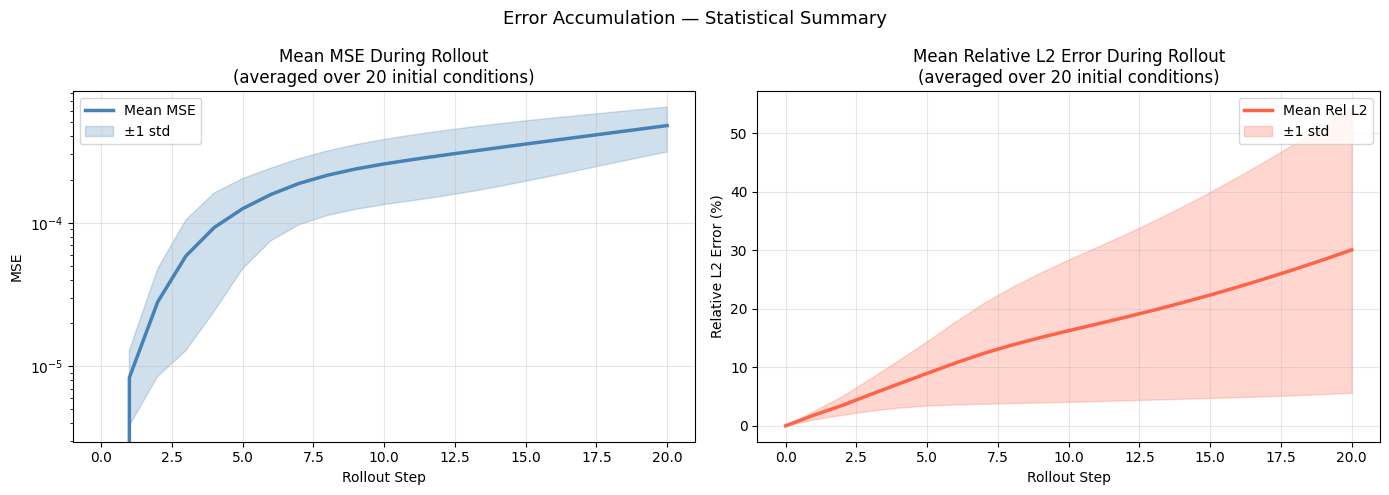

ROLLOUT ERROR SUMMARY (mean ± std over 20 trials)
  Step      MSE mean    RelL2 mean (%)   RelL2 std (%)
-------------------------------------------------------
     0      0.00e+00             0.000           0.000
     1      8.34e-06             1.820           0.742
     5      1.25e-04             8.961           5.499
    10      2.57e-04            16.255          12.154
    15      3.53e-04            22.354          17.599
    20      4.75e-04            30.062          24.411


In [7]:
steps = np.arange(n_rollout_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── MSE ─────────────────────────────────────────────
axes[0].plot(steps, mean_mse, color="steelblue", linewidth=2.5,
             label="Mean MSE")
axes[0].fill_between(
    steps,
    mean_mse - std_mse,
    mean_mse + std_mse,
    alpha=0.25, color="steelblue",
    label="±1 std"
)
axes[0].set_xlabel("Rollout Step")
axes[0].set_ylabel("MSE")
axes[0].set_title(f"Mean MSE During Rollout\n"
                  f"(averaged over {n_test_rollouts} initial conditions)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")

# ── Relative L2 ─────────────────────────────────────
axes[1].plot(steps, mean_rel_l2 * 100, color="tomato", linewidth=2.5,
             label="Mean Rel L2")
axes[1].fill_between(
    steps,
    (mean_rel_l2 - std_rel_l2) * 100,
    (mean_rel_l2 + std_rel_l2) * 100,
    alpha=0.25, color="tomato",
    label="±1 std"
)
axes[1].set_xlabel("Rollout Step")
axes[1].set_ylabel("Relative L2 Error (%)")
axes[1].set_title(f"Mean Relative L2 Error During Rollout\n"
                  f"(averaged over {n_test_rollouts} initial conditions)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Error Accumulation — Statistical Summary", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone8_error_accumulation_mean.png", dpi=150)
plt.show()

# ── print summary table ────────────────────────────
print("=" * 55)
print("ROLLOUT ERROR SUMMARY (mean ± std over 20 trials)")
print("=" * 55)
print(f"{'Step':>6}  {'MSE mean':>12}  {'RelL2 mean (%)':>16}  {'RelL2 std (%)':>14}")
print("-" * 55)
for s in [0, 1, 5, 10, 15, 20]:
    print(f"{s:>6}  {mean_mse[s]:>12.2e}  "
          f"{mean_rel_l2[s]*100:>16.3f}  "
          f"{std_rel_l2[s]*100:>14.3f}")

Cell 8 — Physical sanity check during rollout

Physical sanity checks during rollout:
(These would catch catastrophic failure modes)

Min CNN value across all rollout steps : -0.007041
  (small negatives near zero are acceptable)
  (large negatives would indicate instability)

Max CNN value across all rollout steps : 0.994936
  (should never exceed initial max of 0.9949)


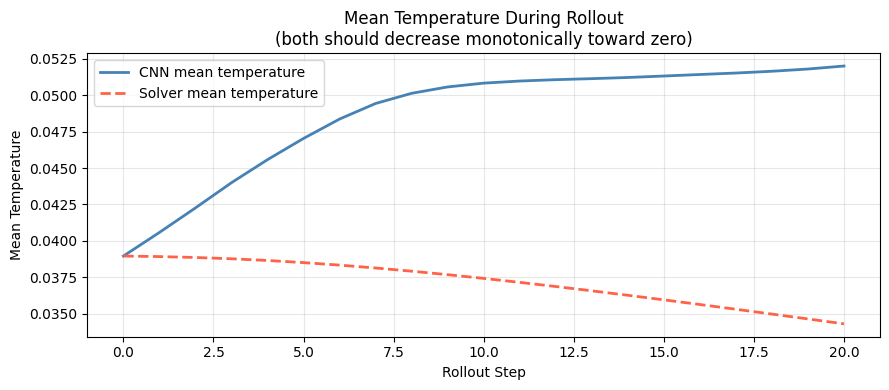


Boundary condition violations during rollout: 16 / 21 steps
✗ CNN violates BC at some steps — note as a limitation.


In [12]:
print("Physical sanity checks during rollout:")
print("(These would catch catastrophic failure modes)\n")

# check 1: do CNN predictions stay non-negative?
min_vals = [cnn_snaps[s].min() for s in range(n_rollout + 1)]
print(f"Min CNN value across all rollout steps : {min(min_vals):.6f}")
print(f"  (small negatives near zero are acceptable)")
print(f"  (large negatives would indicate instability)")

# check 2: do CNN predictions stay bounded?
max_vals = [cnn_snaps[s].max() for s in range(n_rollout + 1)]
print(f"\nMax CNN value across all rollout steps : {max(max_vals):.6f}")
print(f"  (should never exceed initial max of {T0.max():.4f})")

# check 3: does the CNN field evolve monotonically toward zero?
cnn_means = [cnn_snaps[s].mean() for s in range(n_rollout + 1)]
true_means = [true_snaps[s].mean() for s in range(n_rollout + 1)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cnn_means,  label="CNN mean temperature",    color="steelblue", linewidth=2)
ax.plot(true_means, label="Solver mean temperature", color="tomato",
        linewidth=2, linestyle="--")
ax.set_xlabel("Rollout Step")
ax.set_ylabel("Mean Temperature")
ax.set_title("Mean Temperature During Rollout\n"
             "(both should decrease monotonically toward zero)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/milestone8_mean_temperature.png", dpi=150)
plt.show()

# check 4: is the CNN boundary still zero during rollout?
boundary_violations = 0
for s in range(n_rollout + 1):
    snap = cnn_snaps[s]
    if (np.abs(snap[0,:]).max() > 0.01 or
        np.abs(snap[-1,:]).max() > 0.01 or
        np.abs(snap[:,0]).max() > 0.01 or
        np.abs(snap[:,-1]).max() > 0.01):
        boundary_violations += 1

print(f"\nBoundary condition violations during rollout: "
      f"{boundary_violations} / {n_rollout+1} steps")
if boundary_violations == 0:
    print("✓ CNN respects Dirichlet BC throughout rollout.")
else:
    print("✗ CNN violates BC at some steps — note as a limitation.")

Cell 9 — Save rollout results

In [9]:
import json

rollout_results = {
    "n_rollout_steps"  : n_rollout_steps,
    "n_trials"         : n_test_rollouts,
    "stride"           : stride,
    "physical_time_per_step" : float(stride * dt),
    "mean_mse_per_step"    : mean_mse.tolist(),
    "std_mse_per_step"     : std_mse.tolist(),
    "mean_rel_l2_per_step" : mean_rel_l2.tolist(),
    "std_rel_l2_per_step"  : std_rel_l2.tolist(),
    "error_growth_factor"  : float(
        mean_rel_l2[n_rollout_steps] / max(mean_rel_l2[1], 1e-10)
    ),
}

with open("../results/rollout_results.json", "w") as f:
    json.dump(rollout_results, f, indent=2)

print("✓ Rollout results saved to results/rollout_results.json")
print(f"\nError growth factor (step {n_rollout_steps} vs step 1): "
      f"{rollout_results['error_growth_factor']:.2f}x")
print("\nInterpretation guide:")
print("  < 2x  : excellent stability, errors barely accumulate")
print("  2–5x  : acceptable, errors grow but remain bounded")
print("  5–10x : moderate accumulation, surrogate degrades over time")
print("  > 10x : significant instability, long rollouts unreliable")

✓ Rollout results saved to results/rollout_results.json

Error growth factor (step 20 vs step 1): 16.52x

Interpretation guide:
  < 2x  : excellent stability, errors barely accumulate
  2–5x  : acceptable, errors grow but remain bounded
  5–10x : moderate accumulation, surrogate degrades over time
  > 10x : significant instability, long rollouts unreliable


In [13]:
# Measure effective diffusivity learned by the CNN
# Compare how fast heat decays in CNN vs solver

cnn_means  = np.array([cnn_snaps[s].mean()  for s in range(n_rollout + 1)])
true_means = np.array([true_snaps[s].mean() for s in range(n_rollout + 1)])

# fit exponential decay to both: mean(t) ~ A * exp(-lambda * t)
from scipy.optimize import curve_fit

def exp_decay(t, A, lam):
    return A * np.exp(-lam * t)

steps      = np.arange(n_rollout + 1)
phys_times = steps * stride * dt

try:
    solver_params, _ = curve_fit(exp_decay, phys_times, true_means,
                                  p0=[true_means[0], 1.0])
    cnn_params, _    = curve_fit(exp_decay, phys_times, cnn_means,
                                  p0=[cnn_means[0], 1.0])

    print(f"Solver effective decay rate  λ = {solver_params[1]:.4f}")
    print(f"CNN effective decay rate     λ = {cnn_params[1]:.4f}")
    print(f"Ratio (CNN/Solver)             = {cnn_params[1]/solver_params[1]:.4f}")
    print()
    print("Interpretation:")
    print(f"  CNN decays {(1 - cnn_params[1]/solver_params[1])*100:.1f}% slower than the true solver.")
    print(f"  This is the effective diffusivity underestimation.")
except Exception as e:
    print(f"Curve fit failed: {e}")
    print("Try manually comparing means at step 0 and step 20.")
    print(f"Solver decay: {true_means[0]:.4f} → {true_means[-1]:.4f}  "
          f"({(1-true_means[-1]/true_means[0])*100:.1f}% drop)")
    print(f"CNN decay:    {cnn_means[0]:.4f} → {cnn_means[-1]:.4f}  "
          f"({(1-cnn_means[-1]/cnn_means[0])*100:.1f}% change)")

Solver effective decay rate  λ = 0.1147
CNN effective decay rate     λ = -0.1980
Ratio (CNN/Solver)             = -1.7259

Interpretation:
  CNN decays 272.6% slower than the true solver.
  This is the effective diffusivity underestimation.
